# Loss Functions for Regression and Classification

Loss functions tell a model **how wrong its predictions are**.  
Training tries to adjust model parameters so that this value becomes smaller.


## Things covered
- the difference between a **loss function** and an **evaluation metric**
- the mathematics and intuition behind major regression losses
- how outliers change MSE, MAE, Median Absolute Error, and Huber Loss
- the role of `delta` in Huber Loss
- binary and multiclass cross-entropy
- hinge loss and focal loss
- NumPy, scikit-learn, Keras, and PyTorch code snippets

## 1. Loss function versus evaluation metric

These terms are related, but they are not always identical.

- A **loss function** is minimized while the model is learning.
- An **evaluation metric** is used to judge the trained model.
- Some functions can be used as both, such as MSE, MAE, and log loss.
- Some are mainly evaluation metrics. For example, Median Absolute Error is useful for reporting robust performance but is inconvenient for gradient-based optimization because it is not smooth.

For one observation, define the prediction error as:


$$
e = y - \hat{y}
$$


where:

- $y$ is the true value
- $\hat{y}$ is the predicted value
- $e$ is the prediction error

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    mean_absolute_percentage_error,
    log_loss,
    hinge_loss,
)

pd.set_option("display.precision", 4)

# Part I — Regression losses

Regression predicts a continuous number, such as price, temperature, demand, or income.

## 2. Mean Squared Error — MSE


$$
\mathrm{MSE}(y,\hat{y})
=
\frac{1}{n}
\sum_{i=1}^{n}
\left(y_i-\hat{y}_i\right)^2
$$


MSE squares every error.

- Small errors receive a small penalty.
- Large errors receive a much larger penalty.
- It is smooth and differentiable everywhere.
- It is highly sensitive to outliers.
- Its unit is the **square** of the target unit.

An error of 2 contributes $2^2=4$.  
An error of 10 contributes $10^2=100$.

Therefore, one very bad prediction can strongly influence MSE.

In [2]:
y_true = np.array([10, 20, 30, 40])
y_pred = np.array([12, 18, 27, 50])

mse = mean_squared_error(y_true, y_pred)
mse

29.25

## 3. Root Mean Squared Error — RMSE


$$
\mathrm{RMSE}(y,\hat{y})
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(y_i-\hat{y}_i\right)^2
}
$$


RMSE is the square root of MSE.

- It still penalizes large errors strongly.
- Unlike MSE, it returns to the **original unit** of the target.
- It is often easier to explain to stakeholders.

If house prices are measured in dollars, RMSE is also expressed in dollars.

In [3]:
rmse = mean_squared_error(y_true, y_pred) ** 0.5
rmse

5.408326913195984

## 4. Mean Absolute Error — MAE


$$
\mathrm{MAE}(y,\hat{y})
=
\frac{1}{n}
\sum_{i=1}^{n}
\left|y_i-\hat{y}_i\right|
$$


MAE takes the absolute size of every error.

- Errors grow linearly instead of quadratically.
- It is more resistant to outliers than MSE.
- It is expressed in the original target unit.
- Its derivative is not defined exactly at zero, although optimization libraries handle this using subgradients.

An error of 2 contributes 2.  
An error of 10 contributes 10.

In [4]:
mae = mean_absolute_error(y_true, y_pred)
mae

4.25

## 5. Median Absolute Error — MedAE


$$
\mathrm{MedAE}(y,\hat{y})
=
\mathrm{median}
\left(
\left|y_1-\hat{y}_1\right|,
\ldots,
\left|y_n-\hat{y}_n\right|
\right)
$$


Instead of averaging all absolute errors, this metric selects the **middle absolute error**.

- It is extremely resistant to a small number of severe outliers.
- It describes the error of a typical observation.
- It can hide rare but disastrous mistakes.
- It is mainly used as an evaluation metric, not as a standard differentiable training loss.

Suppose the absolute errors are:


$$
[1,\ 2,\ 2,\ 3,\ 100]
$$


MAE is heavily affected by 100, but the median absolute error is only 2.

In [5]:
medae = median_absolute_error(y_true, y_pred)
medae

2.5

## 6. Mean Absolute Percentage Error — MAPE


$$
\mathrm{MAPE}
=
\frac{100}{n}
\sum_{i=1}^{n}
\left|
\frac{y_i-\hat{y}_i}{y_i}
\right|
$$


MAPE expresses error as a percentage.

- It is easy to communicate.
- It is independent of the target's measurement scale.
- It becomes undefined or unstable when actual values are zero or very close to zero.
- It treats overprediction and underprediction asymmetrically in practical percentage interpretation.

Use MAPE only when zero and near-zero actual values are not a problem.

In [6]:
mape_percent = mean_absolute_percentage_error(y_true, y_pred) * 100
mape_percent

16.25

## 7. Huber Loss

Huber Loss combines the useful behavior of MSE and MAE.

For an error $e=y-\hat{y}$:


$$
L_{\delta}(e)=
\begin{cases}
\frac{1}{2}e^2, & |e|\leq\delta \\[4pt]
\delta\left(|e|-\frac{1}{2}\delta\right), & |e|>\delta
\end{cases}
$$


### What `delta` does

- When the absolute error is **smaller than or equal to `delta`**, Huber behaves like MSE.
- When the absolute error is **larger than `delta`**, Huber behaves like MAE.
- A smaller `delta` makes the loss behave more like MAE.
- A larger `delta` makes it behave more like MSE.

Huber Loss is differentiable everywhere, including at the transition points $-\delta$ and $+\delta$.  
Its second derivative is not continuous at those transition points.

This makes Huber smooth enough for gradient-based learning while reducing the influence of extreme outliers.

In [7]:
def huber_loss(y_true, y_pred, delta=1.0):
    error = np.asarray(y_true) - np.asarray(y_pred)
    absolute_error = np.abs(error)

    loss = np.where(
        absolute_error <= delta,
        0.5 * error**2,
        delta * (absolute_error - 0.5 * delta),
    )
    return np.mean(loss)


huber_loss(y_true, y_pred, delta=3.0)

np.float64(8.5)

## 8. Log-Cosh Loss


$$
\mathrm{LogCosh}
=
\frac{1}{n}
\sum_{i=1}^{n}
\log\left(\cosh(y_i-\hat{y}_i)\right)
$$


Log-Cosh is approximately:

- quadratic for small errors
- linear for large errors

It behaves similarly to Huber Loss but has no `delta` threshold. It is smooth and twice differentiable, which can be useful for gradient-based optimization.

A numerically stable implementation should avoid directly calculating `cosh` for very large errors.

In [8]:
def log_cosh_loss(y_true, y_pred):
    error = np.asarray(y_pred) - np.asarray(y_true)

    # Stable equivalent of log(cosh(error))
    per_observation = (
        error
        + np.log1p(np.exp(-2.0 * error))
        - np.log(2.0)
    )
    return np.mean(per_observation)


log_cosh_loss(y_true, y_pred)

np.float64(3.56654670519868)

## 9. Quantile Loss — Pinball Loss

Quantile Loss is useful when we do not only want the conditional mean.

For quantile $q$, where $0<q<1$:


$$
L_q(y,\hat{y})
=
\begin{cases}
q(y-\hat{y}), & y\geq\hat{y} \\[4pt]
(1-q)(\hat{y}-y), & y<\hat{y}
\end{cases}
$$


- $q=0.50$ estimates the median.
- $q=0.90$ estimates a high conditional quantile.
- Higher quantiles penalize underprediction more strongly.
- Lower quantiles penalize overprediction more strongly.

This is useful for prediction intervals, demand planning, risk estimation, and asymmetric business costs.

In [9]:
def quantile_loss(y_true, y_pred, q=0.5):
    error = np.asarray(y_true) - np.asarray(y_pred)
    return np.mean(np.maximum(q * error, (q - 1) * error))


for q in [0.1, 0.5, 0.9]:
    print(f"q={q}: {quantile_loss(y_true, y_pred, q=q):.4f}")

q=0.1: 2.8250
q=0.5: 2.1250
q=0.9: 1.4250


## 10. How the regression losses respond to error

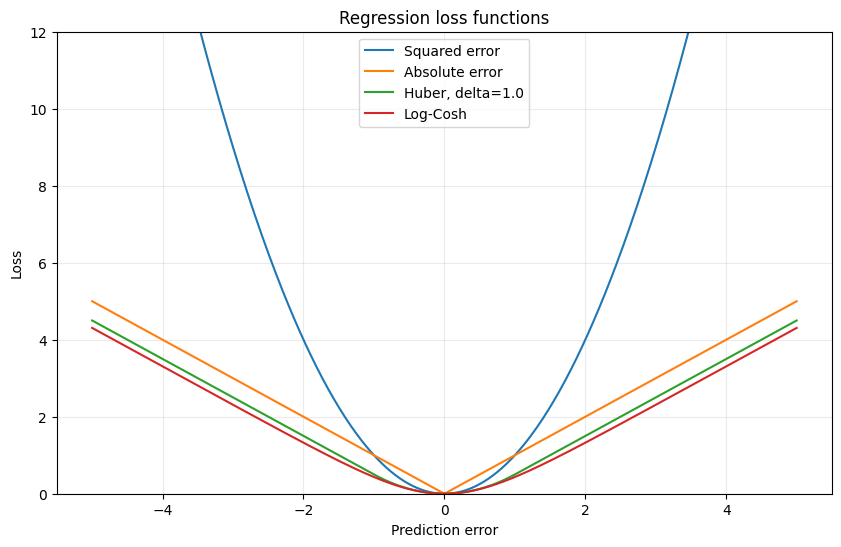

In [10]:
errors = np.linspace(-5, 5, 500)
delta = 1.0

mse_curve = errors**2
mae_curve = np.abs(errors)
huber_curve = np.where(
    np.abs(errors) <= delta,
    0.5 * errors**2,
    delta * (np.abs(errors) - 0.5 * delta),
)
log_cosh_curve = (
    errors + np.log1p(np.exp(-2 * errors)) - np.log(2)
)

plt.figure(figsize=(10, 6))
plt.plot(errors, mse_curve, label="Squared error")
plt.plot(errors, mae_curve, label="Absolute error")
plt.plot(errors, huber_curve, label=f"Huber, delta={delta}")
plt.plot(errors, log_cosh_curve, label="Log-Cosh")
plt.xlabel("Prediction error")
plt.ylabel("Loss")
plt.title("Regression loss functions")
plt.ylim(0, 12)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 11. Outlier experiment

The next example keeps most predictions unchanged and introduces one extreme mistake.  
This shows why MSE and RMSE react more strongly than MAE and Median Absolute Error.

In [11]:
actual = np.array([10, 12, 14, 16, 18], dtype=float)

ordinary_predictions = np.array([11, 11, 15, 15, 19], dtype=float)
outlier_predictions = np.array([11, 11, 15, 15, 60], dtype=float)


def regression_metric_summary(y, prediction):
    return {
        "MSE": mean_squared_error(y, prediction),
        "RMSE": mean_squared_error(y, prediction) ** 0.5,
        "MAE": mean_absolute_error(y, prediction),
        "Median AE": median_absolute_error(y, prediction),
        "Huber delta=2": huber_loss(y, prediction, delta=2),
    }


comparison = pd.DataFrame(
    {
        "Without extreme error": regression_metric_summary(actual, ordinary_predictions),
        "With extreme error": regression_metric_summary(actual, outlier_predictions),
    }
)

comparison["Increase factor"] = (
    comparison["With extreme error"] /
    comparison["Without extreme error"]
)

comparison

,Without extreme error,With extreme error,Increase factor
MSE,1.0,353.6000,353.6000
RMSE,1.0,18.8043,18.8043
MAE,1.0,9.2000,9.2000
Median AE,1.0,1.0000,1.0000
Huber delta=2,0.5,16.8000,33.6000


## 12. Regression loss selection guide

| Situation | Good starting choice | Why |
|---|---|---|
| Large mistakes must be punished strongly | MSE or RMSE | Squaring amplifies large errors |
| Outliers exist and should not dominate | MAE | Linear penalty is more robust |
| Need a robust description of typical error | Median Absolute Error | Ignores the magnitude of extreme tails |
| Want MSE near zero and MAE for outliers | Huber Loss | Smooth robust compromise |
| Want a smooth robust loss without tuning `delta` | Log-Cosh | Smooth approximation to MAE |
| Need percentage interpretation | MAPE | Easy to communicate, but avoid zeros |
| Underprediction and overprediction have different costs | Quantile Loss | Supports asymmetric penalties |

# Part II — Classification losses

Classification models usually output either:

- a probability, such as 0.87 for the positive class
- a vector of class probabilities
- a raw decision score or **logit**

## 13. Binary Cross-Entropy — Binary Log Loss

For binary labels $y\in\{0,1\}$ and predicted positive-class probability $p$:


$$
\mathrm{BCE}
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$


Binary cross-entropy evaluates both correctness and confidence.

For a true class of 1:

- prediction 0.99 gives a very small loss
- prediction 0.60 gives a moderate loss
- prediction 0.01 gives a huge loss

Therefore, confidently wrong predictions are penalized heavily.

In [12]:
binary_y = np.array([1, 0, 1, 1])
binary_probabilities = np.array([0.90, 0.20, 0.70, 0.10])

binary_log_loss = log_loss(binary_y, binary_probabilities)
binary_log_loss

0.7469410259762035

In [13]:
def binary_cross_entropy(y_true, probability, epsilon=1e-15):
    y_true = np.asarray(y_true)
    probability = np.clip(np.asarray(probability), epsilon, 1 - epsilon)

    loss = -(
        y_true * np.log(probability)
        + (1 - y_true) * np.log(1 - probability)
    )
    return np.mean(loss)


binary_cross_entropy(binary_y, binary_probabilities)

np.float64(0.7469410259762035)

## 14. Why probabilities are clipped

The logarithm of zero is undefined:


$$
\log(0)=-\infty
$$


For numerical safety, probabilities are commonly clipped to a tiny interval such as:


$$
[10^{-15},\ 1-10^{-15}]
$$


In deep-learning libraries, prefer loss functions that accept **logits** directly because they combine transformations more safely.

- PyTorch: `BCEWithLogitsLoss`
- Keras: `BinaryCrossentropy(from_logits=True)`

## 15. Categorical Cross-Entropy

For $C$ mutually exclusive classes:


$$
\mathrm{CCE}
=
-\frac{1}{n}
\sum_{i=1}^{n}
\sum_{c=1}^{C}
y_{ic}\log(p_{ic})
$$


Only the probability assigned to the correct class contributes when labels are one-hot encoded.

Use:

- **categorical cross-entropy** for one-hot labels
- **sparse categorical cross-entropy** for integer labels such as `0, 1, 2`

The predicted probabilities across classes normally come from softmax and sum to 1.

In [14]:
multiclass_y = np.array([0, 2, 1])

multiclass_probabilities = np.array([
    [0.80, 0.10, 0.10],
    [0.10, 0.20, 0.70],
    [0.20, 0.60, 0.20],
])

multiclass_log_loss = log_loss(
    multiclass_y,
    multiclass_probabilities,
    labels=[0, 1, 2],
)

multiclass_log_loss

0.3635480396729776

## 16. Hinge Loss

For labels $y\in\{-1,+1\}$ and a raw decision score $s$:


$$
L(y,s)=\max(0,\ 1-ys)
$$


Hinge Loss does not work with probabilities in the same way as cross-entropy.

It asks whether a prediction is:

- on the correct side of the boundary
- far enough from the boundary to satisfy the margin

A correct prediction can still have positive loss when it lies inside the margin.  
Hinge loss is most strongly associated with support vector machines.

In [15]:
hinge_y = np.array([1, -1, 1, -1])
decision_scores = np.array([2.0, -0.4, -0.3, 1.2])

individual_hinge_losses = np.maximum(0, 1 - hinge_y * decision_scores)

pd.DataFrame({
    "true_label": hinge_y,
    "decision_score": decision_scores,
    "hinge_loss": individual_hinge_losses,
})

,true_label,decision_score,hinge_loss
0,1,2.0,0.0
1,-1,-0.4,0.6
2,1,-0.3,1.3
3,-1,1.2,2.2


In [16]:
hinge_loss(hinge_y, decision_scores)

1.025

## 17. Focal Loss

Focal Loss is a modified cross-entropy loss designed for situations with many easy examples and relatively few difficult examples.

For binary classification:


$$
\mathrm{FocalLoss}
=
-\alpha(1-p_t)^\gamma \log(p_t)
$$


where:

- $p_t$ is the probability assigned to the true class
- $\gamma$ reduces the contribution of easy examples
- $\alpha$ can increase the importance of a class

When $\gamma=0$, focal loss becomes ordinary cross-entropy apart from the class weighting term.

Focal loss can help with severe class imbalance, but it is not automatically superior to class weighting, resampling, or threshold tuning. It should be validated for the actual problem.

In [17]:
def binary_focal_loss(
    y_true,
    probability,
    alpha=0.25,
    gamma=2.0,
    epsilon=1e-15,
):
    y_true = np.asarray(y_true)
    probability = np.clip(np.asarray(probability), epsilon, 1 - epsilon)

    p_t = np.where(y_true == 1, probability, 1 - probability)
    alpha_t = np.where(y_true == 1, alpha, 1 - alpha)

    loss = -alpha_t * (1 - p_t) ** gamma * np.log(p_t)
    return np.mean(loss)


binary_focal_loss(binary_y, binary_probabilities)

np.float64(0.12031409384962165)

## 18. Cross-entropy behavior for one positive observation

For a true class of 1, the loss is:


$$
-\log(p)
$$


As the predicted probability approaches zero, the loss rises sharply.

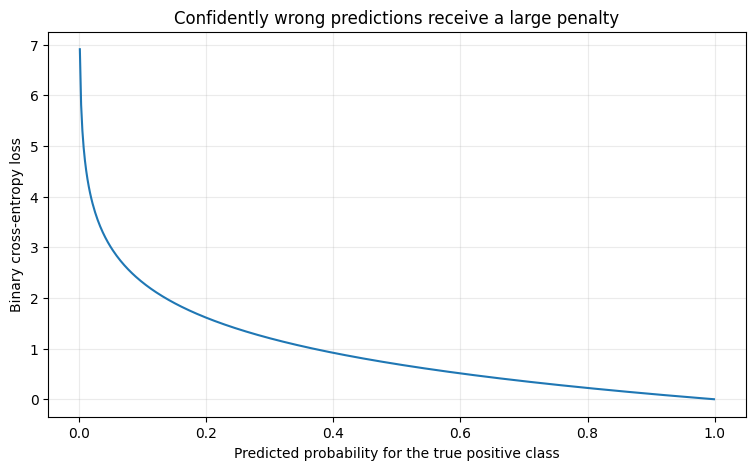

In [18]:
positive_class_probability = np.linspace(0.001, 0.999, 500)
positive_bce = -np.log(positive_class_probability)

plt.figure(figsize=(9, 5))
plt.plot(positive_class_probability, positive_bce)
plt.xlabel("Predicted probability for the true positive class")
plt.ylabel("Binary cross-entropy loss")
plt.title("Confidently wrong predictions receive a large penalty")
plt.grid(alpha=0.25)
plt.show()

## 19. Classification loss selection guide

| Situation | Good starting choice | Notes |
|---|---|---|
| Binary probability prediction | Binary cross-entropy | Standard choice |
| Multiclass, one correct class | Categorical cross-entropy | Usually paired with softmax |
| Integer multiclass labels | Sparse categorical cross-entropy | Avoids manual one-hot encoding |
| Margin-based classifier | Hinge loss | Uses decision scores and labels `-1/+1` |
| Severe imbalance with many easy examples | Focal loss | Focuses learning on harder observations |
| Imbalanced binary classification | Weighted BCE | Often a simpler first approach than focal loss |

# Part III — Practical code snippets

## 20. scikit-learn evaluation snippets

In scikit-learn, many losses are exposed primarily as metrics.  
For cross-validation, loss scorers are often written with a `neg_` prefix because scikit-learn assumes that a larger score is better.

In [19]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    mean_absolute_percentage_error,
    log_loss,
)

# Regression
mse = mean_squared_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
mae = mean_absolute_error(y_true, y_pred)
median_ae = median_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

# Classification
classification_log_loss = log_loss(binary_y, binary_probabilities)

In [20]:
from sklearn.model_selection import cross_validate

regression_scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "RMSE": "neg_root_mean_squared_error",
    "MedianAE": "neg_median_absolute_error",
}

# Example:
# scores = cross_validate(
#     estimator=model,
#     X=X_train,
#     y=y_train,
#     cv=5,
#     scoring=regression_scoring,
#     n_jobs=-1,
# )
#
# Convert negative scores back to positive errors:
# validation_mae = -scores["test_MAE"].mean()

## 21. Keras loss snippets

In [21]:
# TensorFlow / Keras examples
#
# import tensorflow as tf
#
# regression_model.compile(
#     optimizer="adam",
#     loss=tf.keras.losses.Huber(delta=1.0),
#     metrics=[
#         tf.keras.metrics.MeanAbsoluteError(name="mae"),
#         tf.keras.metrics.RootMeanSquaredError(name="rmse"),
#     ],
# )
#
# binary_model.compile(
#     optimizer="adam",
#     loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
#     metrics=["accuracy"],
# )
#
# multiclass_model.compile(
#     optimizer="adam",
#     loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
#     metrics=["accuracy"],
# )

## 22. PyTorch loss snippets

In [22]:
# PyTorch examples
#
# import torch
# import torch.nn as nn
#
# mse_loss = nn.MSELoss()
# mae_loss = nn.L1Loss()
# huber_loss_fn = nn.HuberLoss(delta=1.0)
#
# # Preferred for binary classification when the model returns raw logits:
# binary_loss_fn = nn.BCEWithLogitsLoss()
#
# # Preferred for multiclass classification:
# # Pass raw logits with shape [batch_size, number_of_classes].
# # Pass integer labels with shape [batch_size].
# multiclass_loss_fn = nn.CrossEntropyLoss()
#
# # Hinge-like margin loss:
# hinge_loss_fn = nn.HingeEmbeddingLoss()

## 23. Important implementation warning: logits versus probabilities

Never blindly apply sigmoid or softmax before every loss.

### PyTorch

- `BCEWithLogitsLoss` expects raw binary logits and internally applies a stable sigmoid operation.
- `CrossEntropyLoss` expects raw multiclass logits and internally performs the required log-softmax calculation.

### Keras

- Set `from_logits=True` when the final layer returns raw logits.
- Set `from_logits=False` when the final layer already returns sigmoid or softmax probabilities.

Applying the probability transformation twice can damage training.

# Final comparison

## Regression

- **MSE:** strongest punishment for large errors; smooth; outlier-sensitive.
- **RMSE:** MSE behavior in the original target unit.
- **MAE:** robust linear penalty; easier to interpret.
- **Median Absolute Error:** highly robust evaluation of typical error.
- **MAPE:** percentage error; unsafe around zero.
- **Huber:** MSE for small errors and MAE-like behavior for large errors.
- **Log-Cosh:** smooth robust alternative without a `delta` threshold.
- **Quantile:** asymmetric loss for medians, intervals, and risk-sensitive predictions.

## Classification

- **Binary cross-entropy:** standard binary probability loss.
- **Categorical cross-entropy:** standard multiclass probability loss.
- **Hinge loss:** margin-based loss using decision scores.
- **Focal loss:** reduces the influence of easy examples and focuses on harder cases.

## Main principle

There is no universally best loss function.  
Choose the loss based on:

1. the prediction task
2. the influence of outliers
3. whether large mistakes deserve extra punishment
4. whether the business costs are asymmetric
5. whether the data are imbalanced
6. whether the model outputs logits, probabilities, or decision scores